# CS4503: Data Analytics and Visualization Lab
## Experiment 4: Data Visualization and Hypothesis Testing

This experiment covers:
- **Part A:** Normal Curves
- **Part B:** Z-test
- **Part C:** T-test
- **Part D:** ANOVA


### Part A: Data Visualization – Normal Curves on UCI Diabetes Dataset
**AIM:** To visualize the distribution of key numerical attributes in the UCI Diabetes dataset using normal curves.


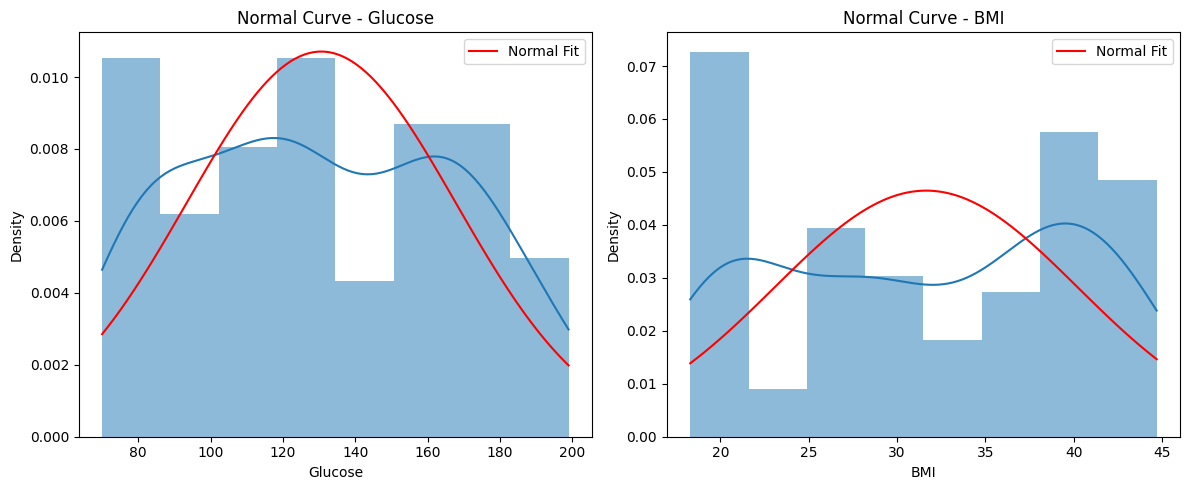

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Load Dataset
uci_diabetes = pd.read_csv("uci_diabetes (3).csv")

# Plot Normal Curves for Glucose and BMI
plt.figure(figsize=(12, 5))

# Normal Curve for Glucose
plt.subplot(1, 2, 1)
sns.histplot(uci_diabetes["Glucose"], kde=True, stat="density", linewidth=0)
x = np.linspace(uci_diabetes["Glucose"].min(), uci_diabetes["Glucose"].max(), 100)
plt.plot(x, norm.pdf(x, uci_diabetes["Glucose"].mean(), uci_diabetes["Glucose"].std()), 'r', label='Normal Fit')
plt.title("Normal Curve - Glucose")
plt.legend()

# Normal Curve for BMI
plt.subplot(1, 2, 2)
sns.histplot(uci_diabetes["BMI"], kde=True, stat="density", linewidth=0)
x = np.linspace(uci_diabetes["BMI"].min(), uci_diabetes["BMI"].max(), 100)
plt.plot(x, norm.pdf(x, uci_diabetes["BMI"].mean(), uci_diabetes["BMI"].std()), 'r', label='Normal Fit')
plt.title("Normal Curve - BMI")
plt.legend()

plt.tight_layout()
plt.show()


### Part B: Hypothesis Testing – Z-Test on UCI Diabetes Dataset
**AIM:** To perform a Z-test on the UCI Diabetes dataset to determine whether the mean Glucose level significantly differs from a given population mean (e.g., 100).

**Hypotheses:**
- **Null Hypothesis ($H_0$):** The mean Glucose level is equal to 100.
- **Alternative Hypothesis ($H_1$):** The mean Glucose level is significantly different from 100.


In [2]:
import pandas as pd
import numpy as np
from statsmodels.stats.weightstats import ztest

# Load Dataset
uci_diabetes = pd.read_csv("uci_diabetes (3).csv")

# Perform Z-Test for Glucose (Testing if mean Glucose differs from 100)
z_stat, p_value = ztest(uci_diabetes["Glucose"], value=100)

# Display Results
print(f"Z-Statistic: {z_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: The mean Glucose level is significantly different from 100.")
else:
    print("Fail to reject the null hypothesis: No significant difference in mean Glucose level.")


Z-Statistic: 8.2146
P-Value: 0.0000
Reject the null hypothesis: The mean Glucose level is significantly different from 100.


### Part C: Performing T-test on Diabetes Datasets
**AIM:** To perform a T-test on the UCI Diabetes and Pima Indians Diabetes datasets to compare the means of numerical variables and determine statistical significance.

**Test Type:** Independent (Unpaired) T-test to compare means between two different groups (UCI vs. Pima).


In [3]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# Load the Datasets
uci_diabetes = pd.read_csv("uci_diabetes (3).csv")
pima_diabetes = pd.read_csv("pima_diabetes (3).csv")

# Select Relevant Numerical Columns
numerical_columns = ["Glucose", "BloodPressure", "BMI"]

# Perform Independent T-test
t_test_results = {}
for col in numerical_columns:
    t_stat, p_value = ttest_ind(uci_diabetes[col], pima_diabetes[col], equal_var=False)
    t_test_results[col] = {"T-statistic": t_stat, "P-value": p_value}

# Convert Results to DataFrame
t_test_df = pd.DataFrame(t_test_results).T
print("Independent T-test Results (UCI vs Pima):")
print(t_test_df)


Independent T-test Results (UCI vs Pima):
               T-statistic   P-value
Glucose          -0.970705  0.332881
BloodPressure     0.286180  0.775040
BMI               0.392477  0.695135


### Part D: Perform ANOVA on Diabetes Datasets
**AIM:** To perform ANOVA (Analysis of Variance) on the UCI Diabetes and Pima Indians Diabetes datasets to analyze differences between multiple group means.


In [4]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway

# Load the Datasets
uci_diabetes = pd.read_csv("uci_diabetes (3).csv")
pima_diabetes = pd.read_csv("pima_diabetes (3).csv")

# Select Relevant Numerical Columns
numerical_columns = ["Glucose", "BloodPressure", "BMI"]

# Perform One-Way ANOVA
anova_results = {}
for col in numerical_columns:
    f_stat, p_value = f_oneway(uci_diabetes[col], pima_diabetes[col])
    anova_results[col] = {"F-statistic": f_stat, "P-value": p_value}

# Convert Results to DataFrame
anova_df = pd.DataFrame(anova_results).T
print("ANOVA Results:")
print(anova_df)


ANOVA Results:
               F-statistic   P-value
Glucose           0.942268  0.332880
BloodPressure     0.081899  0.775040
BMI               0.154039  0.695128
